In [2]:
#loading the temperature files
import pandas as pd

kolkata = pd.read_csv("kolkata.csv", skiprows=11)
delhi = pd.read_csv("delhi.csv", skiprows=11)
mumbai = pd.read_csv("mumbai.csv", skiprows=11)
bangalore = pd.read_csv("bangalore.csv", skiprows=11)

In [3]:
#cleaning column names
for df in [kolkata, delhi, mumbai, bangalore]:
    df.columns = df.columns.str.strip()

In [4]:
#Adding city columns
kolkata["city"] = "Kolkata"
delhi["city"] = "Delhi"
mumbai["city"] = "Mumbai"
bangalore["city"] = "Bangalore"

In [5]:
#combining dataset
df = pd.concat([kolkata, delhi, mumbai, bangalore], ignore_index=True)

In [6]:
#creating proper date
df["date"] = pd.to_datetime(df["YEAR"], format="%Y") + pd.to_timedelta(df["DOY"] - 1, unit="D")

In [7]:
#cleaning data 
df = df.dropna()
df = df[df["YEAR"] < 2026]

In [8]:
# Checking
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,city,date
0,2000,1,16.03,24.26,9.61,Kolkata,2000-01-01
1,2000,2,15.86,24.20,8.22,Kolkata,2000-01-02
2,2000,3,15.30,23.92,7.94,Kolkata,2000-01-03
3,2000,4,15.37,24.12,7.37,Kolkata,2000-01-04
4,2000,5,14.85,23.67,7.00,Kolkata,2000-01-05


In [9]:
#Renaming the columns
df = df.rename(columns={
    "DOY": "day_of_year",
    "T2M": "temp_avg",
    "T2M_MAX": "temp_max",
    "T2M_MIN": "temp_min"
})

In [10]:
df.head()

,YEAR,day_of_year,temp_avg,temp_max,temp_min,city,date
0,2000,1,16.03,24.26,9.61,Kolkata,2000-01-01
1,2000,2,15.86,24.20,8.22,Kolkata,2000-01-02
2,2000,3,15.30,23.92,7.94,Kolkata,2000-01-03
3,2000,4,15.37,24.12,7.37,Kolkata,2000-01-04
4,2000,5,14.85,23.67,7.00,Kolkata,2000-01-05


In [11]:
df.shape

(37988, 7)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37988 entries, 0 to 38329
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         37988 non-null  int64         
 1   day_of_year  37988 non-null  int64         
 2   temp_avg     37988 non-null  float64       
 3   temp_max     37988 non-null  float64       
 4   temp_min     37988 non-null  float64       
 5   city         37988 non-null  object        
 6   date         37988 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 2.3+ MB


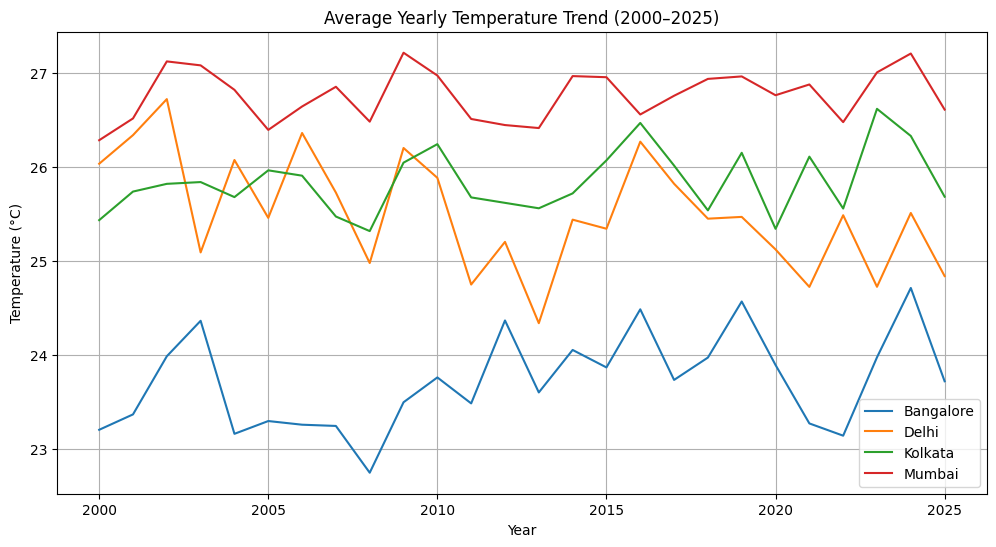

In [13]:
# yearly temperature trend comparison across cities
import matplotlib.pyplot as plt

# Group data
yearly = df.groupby(["YEAR", "city"])["temp_avg"].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

for city in yearly["city"].unique():
    city_data = yearly[yearly["city"] == city]
    plt.plot(city_data["YEAR"], city_data["temp_avg"], label=city)

plt.title("Average Yearly Temperature Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()

In [14]:
# Trying to analyse extreme heat wave , Hot day = temperature ≥ 35°C
# At first Create a “hot day” flag
df["is_hot_day"] = df["temp_max"] >= 35

In [15]:
# Counting hot days per year per city
hot_days = df.groupby(["YEAR", "city"])["is_hot_day"].sum().reset_index()

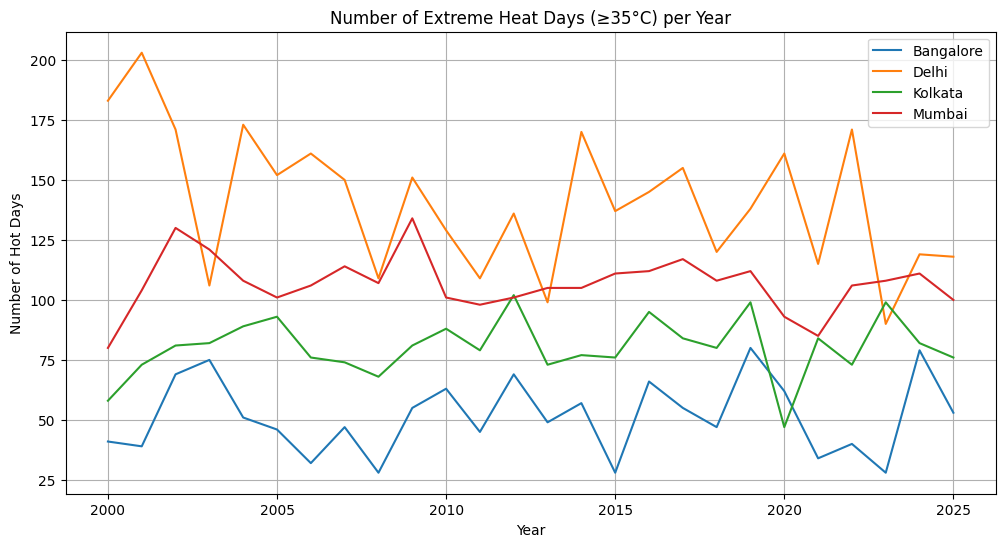

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for city in hot_days["city"].unique():
    city_data = hot_days[hot_days["city"] == city]
    plt.plot(city_data["YEAR"], city_data["is_hot_day"], label=city)

plt.title("Number of Extreme Heat Days (≥35°C) per Year")
plt.xlabel("Year")
plt.ylabel("Number of Hot Days")
plt.legend()
plt.grid()

plt.show()

In [17]:
# Yearly maximum temperature- Hottest day each year for each city
intensity = df.groupby(["YEAR", "city"])["temp_max"].max().reset_index()

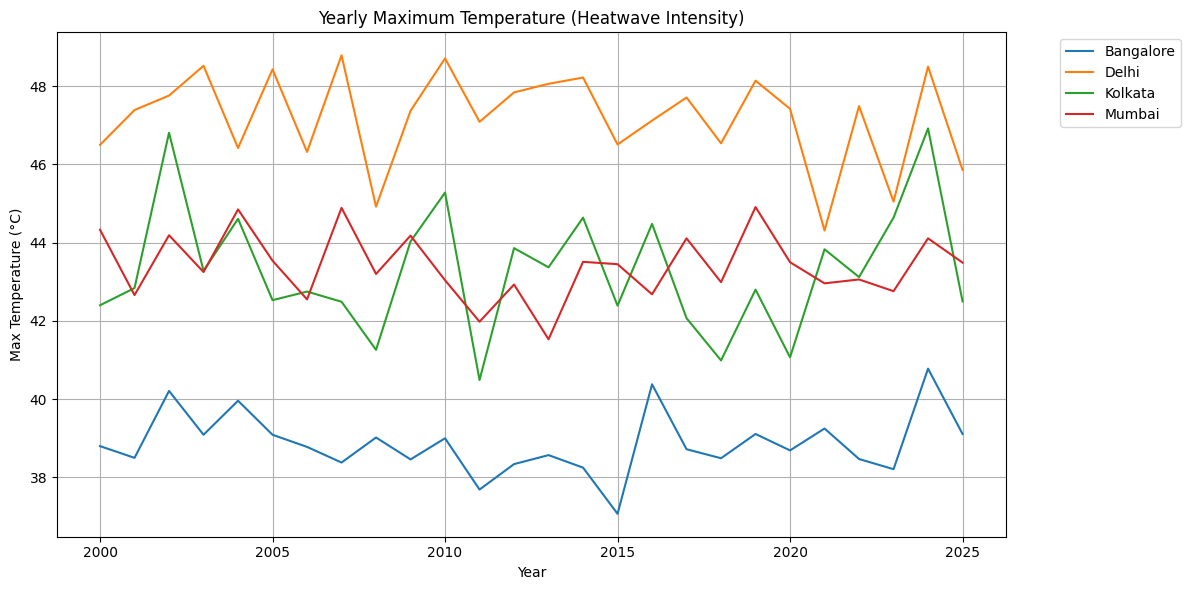

In [18]:
plt.figure(figsize=(12,6))

for city in intensity["city"].unique():
    city_data = intensity[intensity["city"] == city]
    plt.plot(city_data["YEAR"], city_data["temp_max"], label=city)

plt.title("Yearly Maximum Temperature (Heatwave Intensity)")
plt.xlabel("Year")
plt.ylabel("Max Temperature (°C)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

plt.tight_layout()
plt.show()

In [19]:
!pip install folium geopandas

In [20]:
# creating base map - this centers the map on Kolkata
import folium

m = folium.Map(location=[22.57, 88.36], zoom_start=5)
m

In [21]:
# Adding city markers with temperature
# Using latest year data (2025)
latest = df[df["YEAR"] == 2025]

# city coordinates
coords = {
    "Kolkata": [22.57, 88.36],
    "Delhi": [28.61, 77.21],
    "Mumbai": [19.07, 72.87],
    "Bangalore": [12.97, 77.59]
}

for _, row in latest.groupby("city")["temp_max"].max().reset_index().iterrows():
    city = row["city"]
    temp = row["temp_max"]
    
    folium.CircleMarker(
        location=coords[city],
        radius=10,
        popup=f"{city}: {temp:.1f}°C",
        color="red" if temp > 45 else "orange",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m

In [22]:
# creating density based heat map layer
from folium.plugins import HeatMap


In [23]:
#Prepare heat data
#We’ll use:
#latitude, longitude, temperature
heat_data = []

for _, row in latest.groupby("city")["temp_max"].max().reset_index().iterrows():
    city = row["city"]
    temp = row["temp_max"]
    
    lat, lon = coords[city]
    
    # weight = temperature
    heat_data.append([lat, lon, temp])

In [24]:
# Adding heat map layer
HeatMap(
    heat_data,
    radius=25,
    blur=15,
    max_zoom=10
).add_to(m)

m

In [25]:
# Loading shapefile(GADM)
import geopandas as gpd

gdf = gpd.read_file("gadm41_IND_1.shp")
gdf.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,IND.1_1,IND,India,Andaman and Nicobar,Andaman & Nicobar Islands|Andama,NA,Union Territor,Union Territory,NA,IN.AN,NA,"MULTIPOLYGON (((93.79078 6.85139, 93.79092 6.8..."
1,IND.2_1,IND,India,Andhra Pradesh,NA,NA,State,State,NA,IN.AP,IN-AP,"MULTIPOLYGON (((78.73952 13.04549, 78.73218 13..."
2,IND.3_1,IND,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,IN-AR,"POLYGON ((95.3683 27.10736, 95.37366 27.108, 9..."
3,Z07.3_1,Z07,India,Arunachal Pradesh,Agence de la Frontière du Nord-E,NA,State,State,NA,IN.AR,NA,"POLYGON ((94.19125 27.49632, 94.1869 27.49081,..."
4,IND.4_1,IND,India,Assam,NA,NA,State,State,NA,IN.AS,IN-AS,"POLYGON ((92.7545 24.50112, 92.75133 24.49437,..."


In [26]:
wb = gdf[gdf["NAME_1"] == "West Bengal"]
wb

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
40,IND.36_1,IND,India,West Bengal,Bangla|Bengala Occidentale|Benga,NA,State,State,NA,IN.WB,IN-WB,"MULTIPOLYGON (((88.54139 21.63556, 88.54166 21..."


<Axes: >

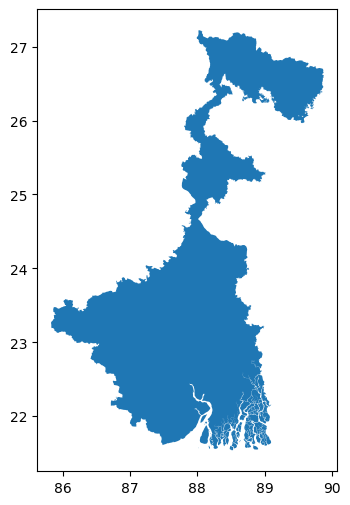

In [27]:
wb.plot(figsize=(6,6))

In [28]:
from shapely.geometry import box
import numpy as np

minx, miny, maxx, maxy = wb.total_bounds

grid_size = 0.1  # you can tweak later

grid_cells = []
for x in np.arange(minx, maxx, grid_size):
    for y in np.arange(miny, maxy, grid_size):
        grid_cells.append(box(x, y, x + grid_size, y + grid_size))

import geopandas as gpd
grid = gpd.GeoDataFrame(geometry=grid_cells, crs=wb.crs)

In [29]:
grid = gpd.overlay(grid, wb, how="intersection")

<Axes: >

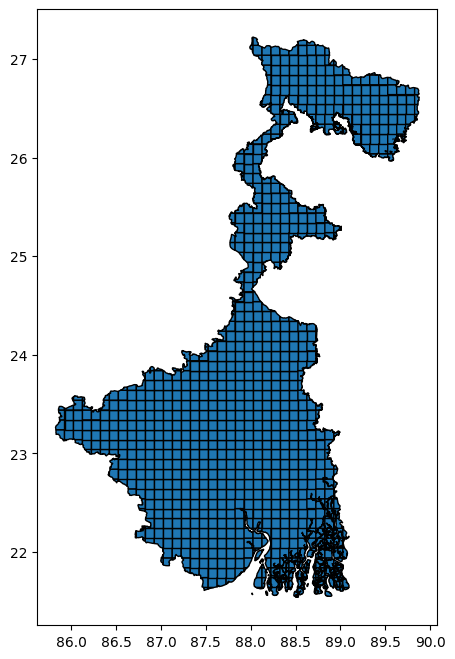

In [30]:
grid.plot(figsize=(8,8), edgecolor="black")

In [31]:
import numpy as np

base_temp = df[df["city"] == "Kolkata"]["temp_avg"].mean()

np.random.seed(42)

grid["temp"] = base_temp + np.random.uniform(-2, 2, len(grid))

<Figure size 1000x800 with 0 Axes>

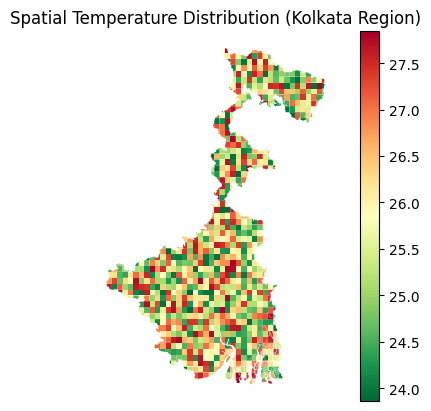

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

grid.plot(
    column="temp",
    cmap="RdYlGn_r",
    legend=True
)

plt.title("Spatial Temperature Distribution (Kolkata Region)")
plt.axis("off")

plt.show()